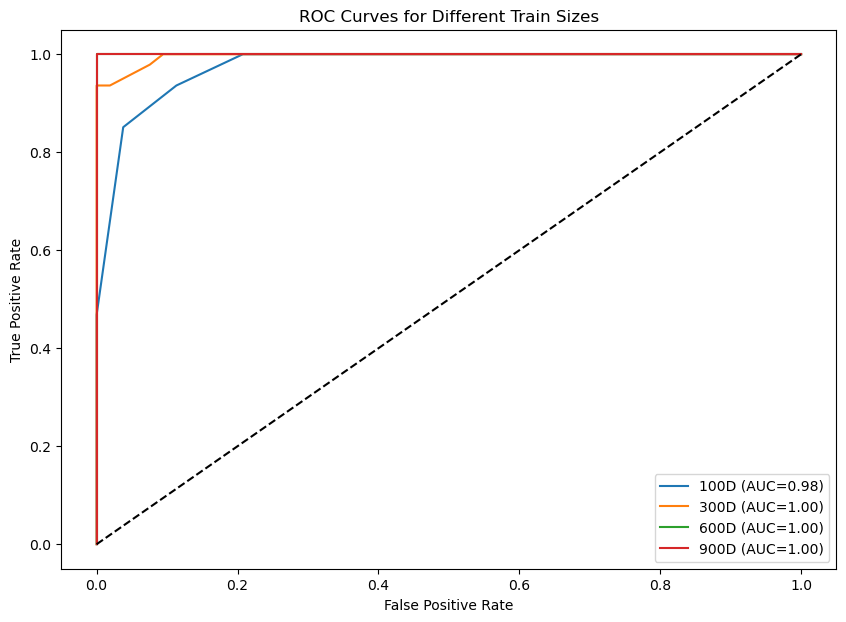

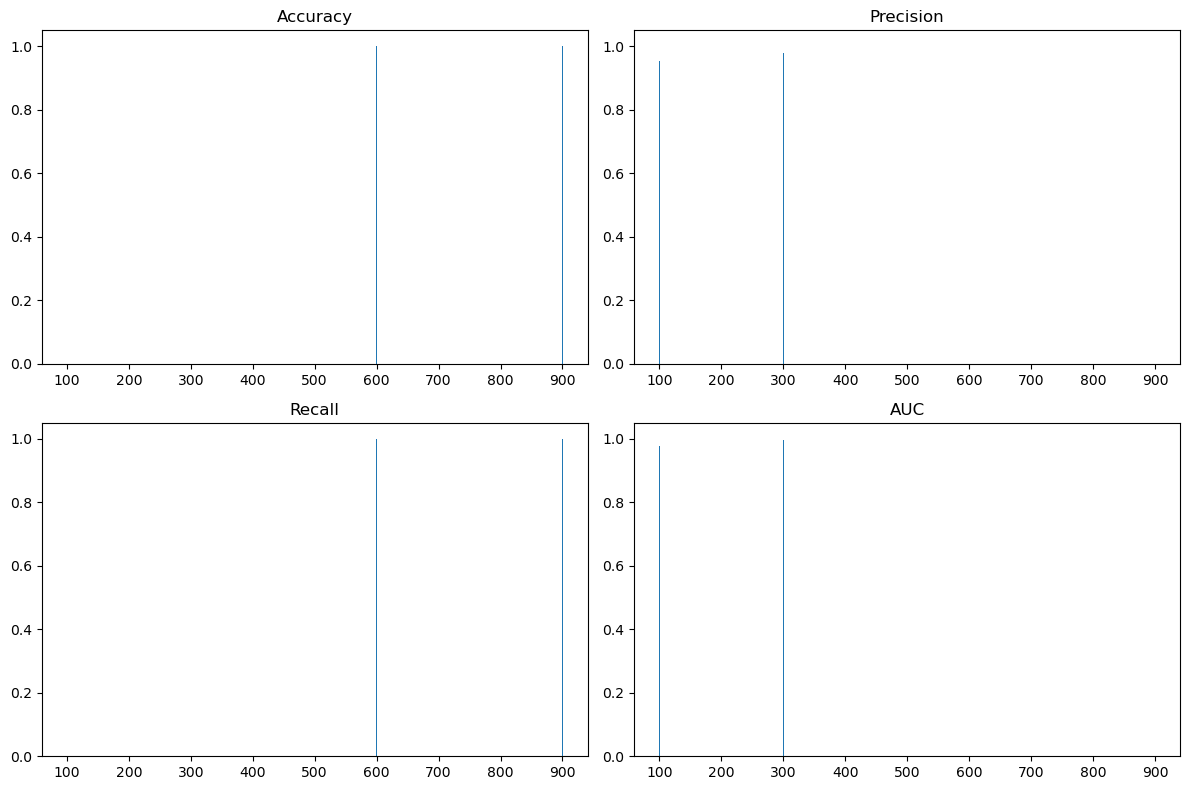

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


data = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\900D_heart_disease_dataset.csv",
                   encoding='ISO-8859-1')
test = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_test_dataset.csv",
                   encoding='ISO-8859-1')


X_train_full = data.drop("target", axis=1)
y_train_full = data["target"]

X_test = test.drop("target", axis=1)
y_test = test["target"]


accuracy_list = []
precision_list = []
recall_list = []
auc_list = []

plt.figure(figsize=(10, 7))

for size in sizes:
    X_small = X_train_full[:size]
    y_small = y_train_full[:size]


    dt = DecisionTreeClassifier()
    grid = GridSearchCV(dt, params, cv=5, scoring="accuracy")
    grid.fit(X_small, y_small)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    auc_list.append(auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{size}D (AUC={auc:.2f})")

# Plot ROC
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Train Sizes")
plt.legend()
plt.show()



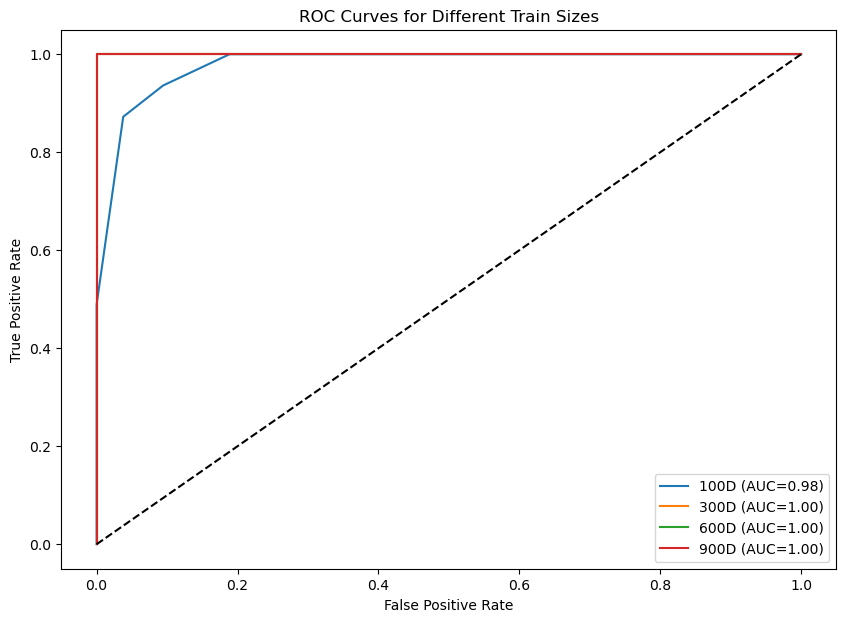

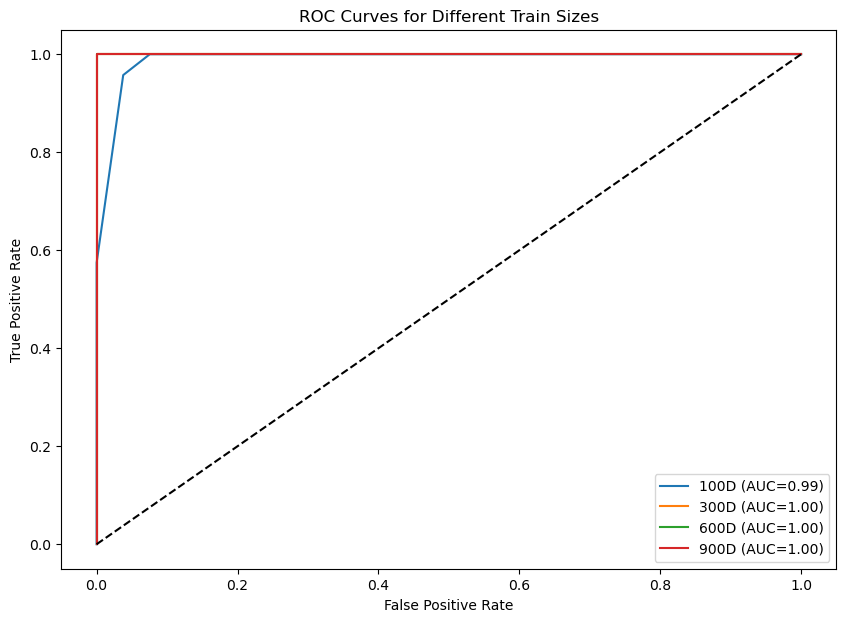

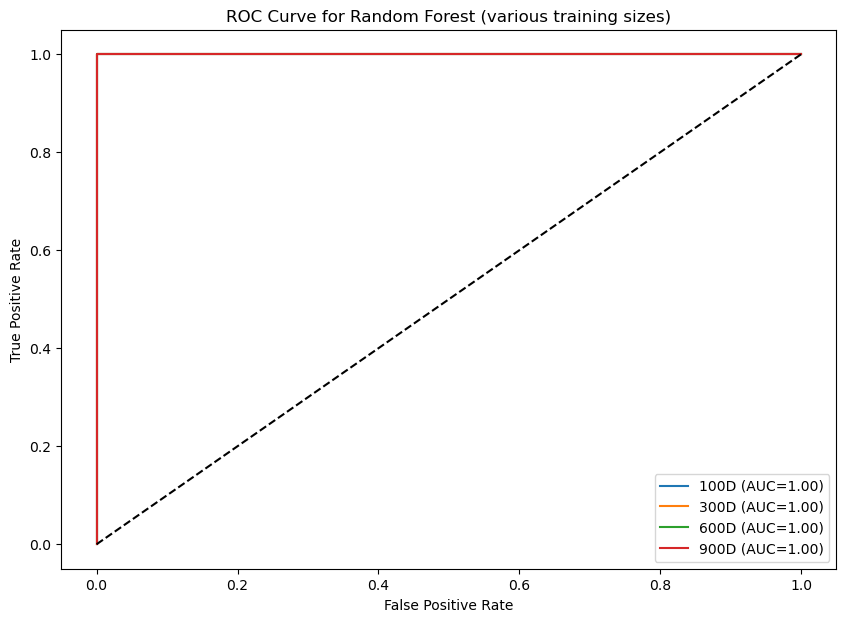

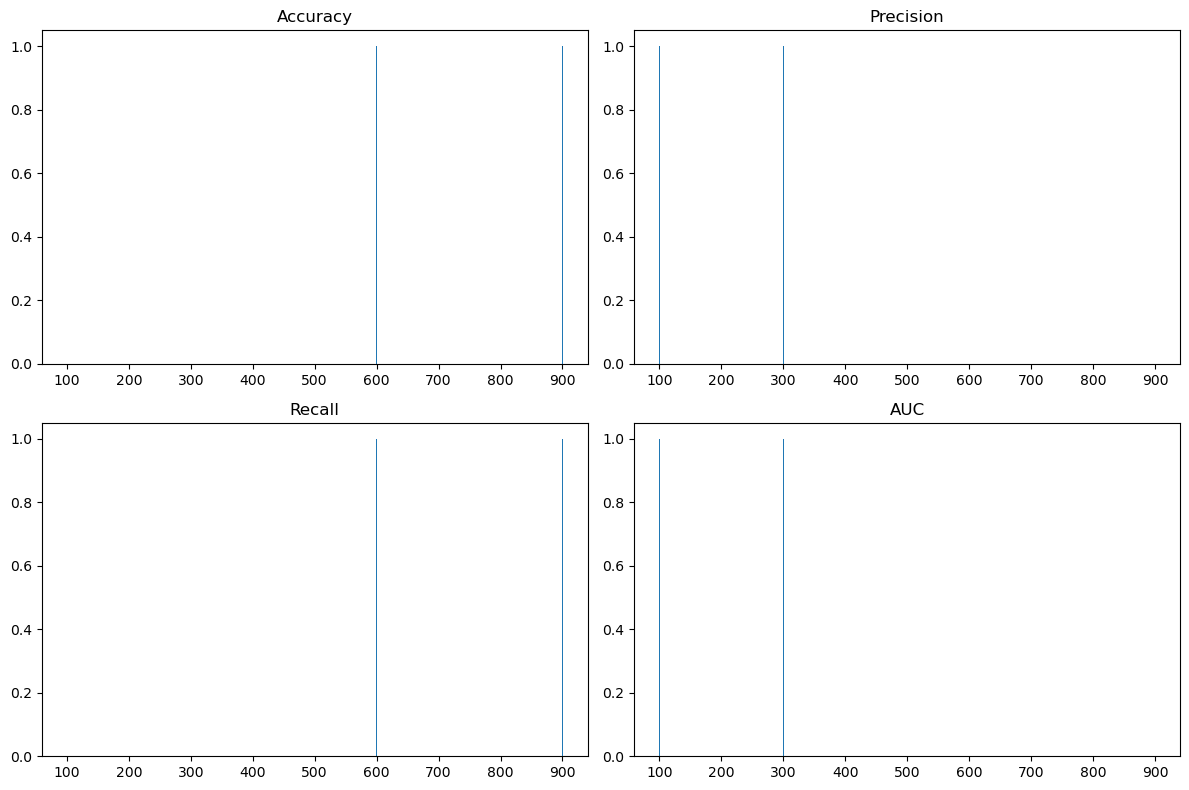